# Lab CNN — 03: Construcción y entrenamiento del modelo CNN

Este notebook implementa y entrena la CNN de clasificación de género (female / male)
usando los datos preprocesados generados en `02_preprocesamiento.ipynb`.

**Flujo del notebook:**
1. Carga de los splits preprocesados (`outputs/data_splits.npz`)
2. Definición de la arquitectura CNN secuencial (≥3 bloques Conv2D + MaxPooling2D)
3. Compilación con `binary_crossentropy` y optimizador Adam
4. Entrenamiento con registro de métricas de exactitud y pérdida
5. Curvas de aprendizaje
6. Evaluación en el conjunto de prueba
7. Guardado del modelo en `models/model.keras`

**Clases:** `0 → female`, `1 → male`

## 0. Imports y configuración de rutas

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Rutas (este notebook vive en scripts/, sube un nivel para llegar a la raíz)
BASE_DIR   = Path().resolve().parent
OUT_DIR    = BASE_DIR / "outputs"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

DATA_PATH  = OUT_DIR / "data_splits.npz"
MODEL_PATH = MODELS_DIR / "model.keras"

# Hiperparámetros
IMG_SHAPE  = (128, 128, 3)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3

print(f"TensorFlow  : {tf.__version__}")
print(f"GPUs        : {tf.config.list_physical_devices('GPU')}")
print(f"data_splits : {DATA_PATH}  →  existe: {DATA_PATH.exists()}")
print(f"Modelo      : {MODEL_PATH}")

2026-05-05 19:38:19.004984: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 19:38:19.882831: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2026-05-05 19:38:21.393564: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/valentinau/miniconda3/envs/labcnn/lib:/usr/lib/wsl/lib
2026-05-05 19:38:21.394483: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/valentinau/miniconda3/envs/labcnn/lib:/usr/lib/wsl/lib
2026-05-05 19:38:21.394496: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nvidia GPU with TensorRT, please make sure the missing libraries mentioned above are installed properly.


TensorFlow  : 2.10.0
GPUs        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
data_splits : /home/valentinau/Proyectos2026-I/LabCNN/outputs/data_splits.npz  →  existe: True
Modelo      : /home/valentinau/Proyectos2026-I/LabCNN/models/model.keras


2026-05-05 19:38:24.349824: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:38:24.436454: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:38:24.436531: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 1. Carga de los datos preprocesados

Se cargan los seis arrays generados por el notebook anterior: `X_train`, `X_val`, `X_test`
(imágenes 128×128×3, float32, rango [0,1]) y sus etiquetas correspondientes.

In [2]:
data = np.load(str(DATA_PATH))
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

print(f"{'Split':>6}  {'X shape':>18}  {'y shape':>10}  female  male")
print("-" * 60)
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:>6}  {str(X.shape):>18}  {str(y.shape):>10}  "
          f"{int((y == 0).sum()):>6}  {int((y == 1).sum()):>6}")

 Split             X shape     y shape  female  male
------------------------------------------------------------
 train  (3792, 128, 128, 3)     (3792,)    1888    1904
   val  (813, 128, 128, 3)      (813,)     405     408
  test  (813, 128, 128, 3)      (813,)     405     408


## 2. Arquitectura del modelo CNN

Se define una CNN secuencial con **tres bloques Conv2D + MaxPooling2D** seguidos de capas densas:

```
Entrada : (128, 128, 3)

Bloque 1:  Conv2D(32, 3×3, relu, same)  →  MaxPooling2D(2×2)  →  [64, 64, 32]
Bloque 2:  Conv2D(64, 3×3, relu, same)  →  MaxPooling2D(2×2)  →  [32, 32, 64]
Bloque 3:  Conv2D(128, 3×3, relu, same) →  MaxPooling2D(2×2)  →  [16, 16, 128]

Flatten                                                          →  32 768
Dense(128, relu)
Dropout(0.5)
Dense(1, sigmoid)                                                →  probabilidad male
```

El `padding='same'` preserva las dimensiones espaciales dentro de cada bloque;
la reducción dimensional la realiza exclusivamente `MaxPooling2D`. El `Dropout(0.5)`
actúa como regularización para mitigar el sobreajuste dado el tamaño moderado del dataset.

In [3]:
model = Sequential([
    # Bloque 1: 128×128×3 → 64×64×32
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=IMG_SHAPE),
    MaxPooling2D((2, 2)),

    # Bloque 2: 64×64×32 → 32×32×64
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Bloque 3: 32×32×64 → 16×16×128
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Cabeza densa
    Flatten(),                          # 16×16×128 = 32 768
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),     # salida binaria
], name="LabCNN")

2026-05-05 19:38:28.340713: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 19:38:28.342610: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:38:28.342736: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:38:28.342782: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built witho

In [4]:
model.summary()

Model: "LabCNN"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d (Conv2D)             (None, 128, 128, 32)      896       


 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         


...

 dense_1 (Dense)             (None, 1)                 129       


Total params: 4,287,809


Trainable params: 4,287,809


Non-trainable params: 0


_________________________________________________________________


## 3. Compilación

Se compila el modelo con:
- **Optimizador:** Adam (lr=1e-3), ajuste adaptativo de la tasa de aprendizaje.
- **Pérdida:** `binary_crossentropy`, adecuada para clasificación binaria con salida sigmoide.
- **Métrica:** `accuracy` para monitorear exactitud por época.

In [5]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
print("Compilación completada.")
print(f"  Optimizador : Adam  (lr={LR})")
print(f"  Pérdida     : binary_crossentropy")
print(f"  Métricas    : accuracy")

Compilación completada.
  Optimizador : Adam  (lr=0.001)
  Pérdida     : binary_crossentropy
  Métricas    : accuracy


## 4. Entrenamiento

Se usan dos callbacks:
- **`EarlyStopping`** (patience=7): detiene el entrenamiento si `val_loss` no mejora y
  restaura los pesos del mejor epoch (`restore_best_weights=True`).
- **`ModelCheckpoint`**: guarda automáticamente el mejor modelo en `models/model.keras`
  cada vez que `val_loss` mejora.

In [6]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

epochs_run = len(history.history["loss"])
print(f"\nEntrenamiento completado: {epochs_run} épocas ejecutadas.")

2026-05-05 19:38:30.598869: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 745537536 exceeds 10% of free system memory.
2026-05-05 19:38:31.336853: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 745537536 exceeds 10% of free system memory.


Epoch 1/30


2026-05-05 19:38:34.147460: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8100


2026-05-05 19:38:36.665652: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 19:38:36.682609: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 19:38:36.682656: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2026-05-05 19:38:36.700249: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 19:38:36.700379: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.



  1/119 [..............................] - ETA: 17:41 - loss: 0.6950 - accuracy: 0.4688

...


117/119 [============================>.] - ETA: 0s - loss: 0.0119 - accuracy: 0.9965

Restoring model weights from the end of the best epoch: 5.



119/119 [==============================] - 4s 33ms/step - loss: 0.0123 - accuracy: 0.9963 - val_loss: 0.1384 - val_accuracy: 0.9828


Epoch 12: early stopping



Entrenamiento completado: 12 épocas ejecutadas.


## 5. Curvas de aprendizaje

Se grafican las curvas de pérdida y exactitud para los conjuntos de entrenamiento y validación.
La brecha entre ambas curvas indica el grado de sobreajuste.

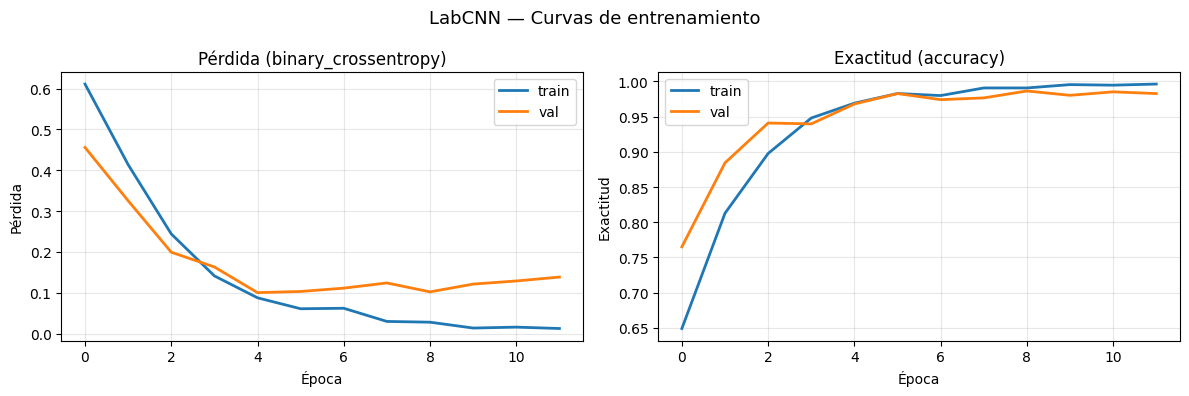

Curvas guardadas en: outputs/curvas_entrenamiento.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
axes[0].plot(history.history["loss"],     label="train", linewidth=2)
axes[0].plot(history.history["val_loss"], label="val",   linewidth=2)
axes[0].set_title("Pérdida (binary_crossentropy)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Pérdida")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exactitud
axes[1].plot(history.history["accuracy"],     label="train", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="val",   linewidth=2)
axes[1].set_title("Exactitud (accuracy)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Exactitud")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("LabCNN — Curvas de entrenamiento", fontsize=13)
plt.tight_layout()

plot_path = OUT_DIR / "curvas_entrenamiento.png"
fig.savefig(str(plot_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Curvas guardadas en: {plot_path.relative_to(BASE_DIR)}")

## 6. Evaluación en el conjunto de prueba

Se evalúa el modelo (con los pesos del mejor epoch restaurados por `EarlyStopping`)
sobre el conjunto de prueba, que no fue visto durante el entrenamiento ni la validación.

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)

best_val_loss = min(history.history["val_loss"])
best_val_acc  = max(history.history["val_accuracy"])
best_epoch    = history.history["val_loss"].index(best_val_loss) + 1

print("=" * 45)
print("  RESULTADOS — LabCNN")
print("=" * 45)
print(f"  Mejor época (val_loss)  : {best_epoch}/{epochs_run}")
print(f"  Mejor val_loss          : {best_val_loss:.4f}")
print(f"  Mejor val_accuracy      : {best_val_acc:.4f} ({best_val_acc * 100:.2f}%)")
print(f"  Test loss               : {test_loss:.4f}")
print(f"  Test accuracy           : {test_acc:.4f} ({test_acc * 100:.2f}%)")
print("=" * 45)

  RESULTADOS — LabCNN
  Mejor época (val_loss)  : 5/12
  Mejor val_loss          : 0.1002
  Mejor val_accuracy      : 0.9865 (98.65%)
  Test loss               : 0.1111
  Test accuracy           : 0.9643 (96.43%)


## 7. Verificación del modelo guardado

`ModelCheckpoint` guardó el mejor modelo durante el entrenamiento. Se verifica que el
archivo existe, se mide su tamaño y se recarga para confirmar que produce el mismo
resultado que el modelo en memoria.

In [9]:
assert MODEL_PATH.exists(), f"El archivo del modelo no se encontró en {MODEL_PATH}"

size_mb = MODEL_PATH.stat().st_size / (1024 ** 2)
print(f"Modelo guardado : {MODEL_PATH.relative_to(BASE_DIR)}")
print(f"Tamaño en disco : {size_mb:.1f} MB")

loaded = tf.keras.models.load_model(str(MODEL_PATH))
_, loaded_acc = loaded.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
print(f"\nExactitud del modelo recargado: {loaded_acc:.4f} — verificación OK")

Modelo guardado : models/model.keras
Tamaño en disco : 49.1 MB



Exactitud del modelo recargado: 0.9643 — verificación OK
